# ECRformer Prediction Visualization

This notebook visualizes predictions exported by `test.py` together with the corresponding dataset inputs and targets.

Recommended export command:

```bash
python test.py --config ecrformer --export-format both
```

Use `index_list` in Cell 2 to display multiple samples at once. Each row shows:

1. SAR mean image
2. Cloudy RGB
3. Prediction RGB
4. Target RGB
5. Error map

RGB images follow the same rendering logic as `test.py`: select `rgb_bands`, apply brightness enhancement, and clip to `[0, 1]`.
If only `pred_rgb` exists, the notebook uses the exported PNG directly. Optional per-band statistics are available only when `pred_npz` exists.

In [1]:
from pathlib import Path
import csv
import json

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

from config import find_config_using_name
from data import find_dataset_using_name
from util.data_split import build_eval_dataset

config_name = 'ecrformer'
run_name = None
split_name = None
results_root = Path('results')
rgb_bands = (3, 2, 1)
png_brightness = 3.0
error_cmap = 'inferno'
show_summary_json = False

In [2]:
def resolve_log_name(config_name, run_name=None):
    return f'{config_name}_{run_name}' if run_name else config_name


def has_prediction_exports(results_dir):
    results_dir = Path(results_dir)
    return (results_dir / 'pred_npz').exists() or (results_dir / 'pred_rgb').exists()


def build_results_dir(results_root, config_name, run_name, split_name):
    return Path(results_root) / resolve_log_name(config_name, run_name) / split_name


def resolve_results_dir(results_root, config_name, run_name, split_name):
    expected_dir = build_results_dir(results_root, config_name, run_name, split_name)
    if has_prediction_exports(expected_dir):
        return expected_dir

    candidate_dirs = []
    config_prefix = resolve_log_name(config_name, run_name)
    for run_dir in sorted(Path(results_root).glob(f'{config_prefix}*')):
        split_dir = run_dir / split_name
        if has_prediction_exports(split_dir):
            candidate_dirs.append(split_dir)

    if not candidate_dirs:
        for split_dir in Path(results_root).glob(f'*/{split_name}'):
            if has_prediction_exports(split_dir):
                candidate_dirs.append(split_dir)

    if candidate_dirs:
        candidate_dirs.sort(key=lambda path: path.stat().st_mtime, reverse=True)
        return candidate_dirs[0]

    raise FileNotFoundError(
        f'No prediction exports were found for split={split_name} under {results_root}. '
        'Run test.py with --export-format png, npz, or both first.'
    )


def render_rgb_like_test(image, bands=(3, 2, 1), brightness=3.0):
    image = np.asarray(image, dtype=np.float32)
    if image.ndim != 3:
        raise ValueError(f'Expected a CHW image, got shape {image.shape}')
    if max(bands) >= image.shape[0]:
        raise ValueError(f'RGB bands {bands} exceed channel count {image.shape[0]}')
    rgb = np.transpose(image[list(bands)], (1, 2, 0))
    return np.clip(rgb * brightness, 0.0, 1.0)


def render_sar_mean(sar):
    sar = np.asarray(sar, dtype=np.float32)
    if sar.ndim != 3:
        raise ValueError(f'Expected a CHW SAR tensor, got shape {sar.shape}')
    return np.clip(sar.mean(axis=0), 0.0, 1.0)


def load_prediction(results_dir, sample_index):
    npz_candidates = sorted((results_dir / 'pred_npz').glob(f'{sample_index:05d}_*.npz'))
    png_candidates = sorted((results_dir / 'pred_rgb').glob(f'{sample_index:05d}_*.png'))

    if npz_candidates:
        prediction_source = npz_candidates[0]
        prediction = np.load(prediction_source)['pred'].astype(np.float32)
        return prediction, prediction_source, 'npz'

    if png_candidates:
        prediction_source = png_candidates[0]
        prediction = np.asarray(Image.open(prediction_source).convert('RGB')).astype(np.float32) / 255.0
        return prediction, prediction_source, 'png'

    raise FileNotFoundError(
        f'No exported prediction was found for sample_index={sample_index} in {results_dir}.'
    )


def prediction_to_display(prediction, prediction_kind, bands=(3, 2, 1), brightness=3.0):
    prediction = np.asarray(prediction, dtype=np.float32)
    if prediction_kind == 'png':
        if prediction.ndim != 3 or prediction.shape[-1] != 3:
            raise ValueError(f'Expected an HWC RGB PNG prediction, got shape {prediction.shape}')
        return np.clip(prediction, 0.0, 1.0)
    return render_rgb_like_test(prediction, bands, brightness)


def compute_error_map(pred_rgb, target_rgb):
    pred_rgb = np.asarray(pred_rgb, dtype=np.float32)
    target_rgb = np.asarray(target_rgb, dtype=np.float32)
    if pred_rgb.shape != target_rgb.shape:
        raise ValueError(f'Prediction RGB shape {pred_rgb.shape} does not match target RGB shape {target_rgb.shape}')
    return np.mean(np.abs(pred_rgb - target_rgb), axis=-1)


def load_sample_metrics(results_dir, sample_index):
    metrics_path = results_dir / 'metrics.csv'
    if not metrics_path.exists():
        return None

    with metrics_path.open('r', encoding='utf-8') as handle:
        reader = csv.DictReader(handle)
        for row in reader:
            if int(row['index']) == sample_index:
                return row
    return None


def load_summary(results_dir):
    summary_path = results_dir / 'summary.json'
    if not summary_path.exists():
        print('summary.json was not found.')
        return None
    return json.loads(summary_path.read_text(encoding='utf-8'))


def format_metrics(metrics_row):
    if metrics_row is None:
        return 'metrics: unavailable'
    keys = ['MAE', 'PSNR', 'SSIM', 'LPIPS']
    return '\n'.join(
        f"{key}={float(metrics_row[key]):.4f}" for key in keys if key in metrics_row
    )


def describe_record(record):
    prediction = np.asarray(record['prediction'])
    return (
        f"index={record['index']} | source={record['prediction_source'].name} | kind={record['prediction_kind']} | "
        f"prediction_shape={prediction.shape} | cloudy_shape={record['sample']['cloudy'].shape} | "
        f"SAR_shape={record['sample']['SAR'].shape} | target_shape={record['sample']['target'].shape}"
    )


def get_prediction_band_means(record):
    if record['prediction_kind'] != 'npz':
        return None
    prediction = np.asarray(record['prediction'], dtype=np.float32)
    if prediction.ndim != 3:
        return None
    return prediction.mean(axis=(1, 2))

config = find_config_using_name(config_name)()
dataset_class = find_dataset_using_name(config.dataset.name)
resolved_split, dataset = build_eval_dataset(config, dataset_class, split_name)
results_dir = resolve_results_dir(
    results_root, config_name, run_name, resolved_split)
summary = load_summary(results_dir)

if show_summary_json and summary is not None:
    print(json.dumps(summary, indent=2, ensure_ascii=False))


Processing paths for test split (season=all)


Indexing ROIs:   0%|          | 0/4 [00:00<?, ?it/s]

Indexing ROIs: 100%|██████████| 4/4 [00:04<00:00,  1.19s/it]

7899 samples found


In [3]:
index_list = np.linspace(0, len(dataset) - 1, num=5, dtype=int).tolist()
# You can customize the index_list to view specific samples.
# index_list = [1, 2, 3, 4]
print(index_list)

[0, 1974, 3949, 5923, 7898]


In [4]:
records = []
for sample_index in index_list:
    sample = dataset[sample_index]
    prediction, prediction_source, prediction_kind = load_prediction(results_dir, sample_index)

    cloudy_rgb = render_rgb_like_test(sample['cloudy'], rgb_bands, png_brightness)
    pred_rgb = prediction_to_display(prediction, prediction_kind, rgb_bands, png_brightness)
    target_rgb = render_rgb_like_test(sample['target'], rgb_bands, png_brightness)
    sar_mean = render_sar_mean(sample['SAR'])
    error_map = compute_error_map(pred_rgb, target_rgb)
    sample_metrics = load_sample_metrics(results_dir, sample_index)

    records.append(
        {
            'index': sample_index,
            'sample': sample,
            'prediction': prediction,
            'prediction_source': prediction_source,
            'prediction_kind': prediction_kind,
            'metrics': sample_metrics,
            'sar_mean': sar_mean,
            'cloudy_rgb': cloudy_rgb,
            'pred_rgb': pred_rgb,
            'target_rgb': target_rgb,
            'error_map': error_map,
        }
    )

print(f'results_dir: {results_dir}')
print(f'number of selected samples: {len(records)}')
for record in records:
    print(describe_record(record))
    if record['metrics'] is not None:
        print('metrics:', record['metrics'])

results_dir: results/ecrformer/test
number of selected samples: 5
index=0 | source=00000_ROIs1158_spring_s2_31_p30.npz | kind=npz | prediction_shape=(13, 256, 256) | cloudy_shape=(13, 256, 256) | SAR_shape=(2, 256, 256) | target_shape=(13, 256, 256)
metrics: {'index': '0', 'sample_id': 'ROIs1158_spring_s2_31_p30', 'RMSE': '0.014396624639630318', 'MAE': '0.009594820439815521', 'PSNR': '36.83478546142578', 'SAM': '2.1062357425689697', 'SSIM': '0.9806602597236633', 'LPIPS': '0.0712052583694458'}
index=1974 | source=01974_ROIs1158_spring_s2_106_p450.npz | kind=npz | prediction_shape=(13, 256, 256) | cloudy_shape=(13, 256, 256) | SAR_shape=(2, 256, 256) | target_shape=(13, 256, 256)
metrics: {'index': '1974', 'sample_id': 'ROIs1158_spring_s2_106_p450', 'RMSE': '0.011560654267668724', 'MAE': '0.007255947683006525', 'PSNR': '38.740352630615234', 'SAM': '1.569230079650879', 'SSIM': '0.9684509038925171', 'LPIPS': '0.07263350486755371'}
index=3949 | source=03949_ROIs1158_spring_s2_140_p902.npz |

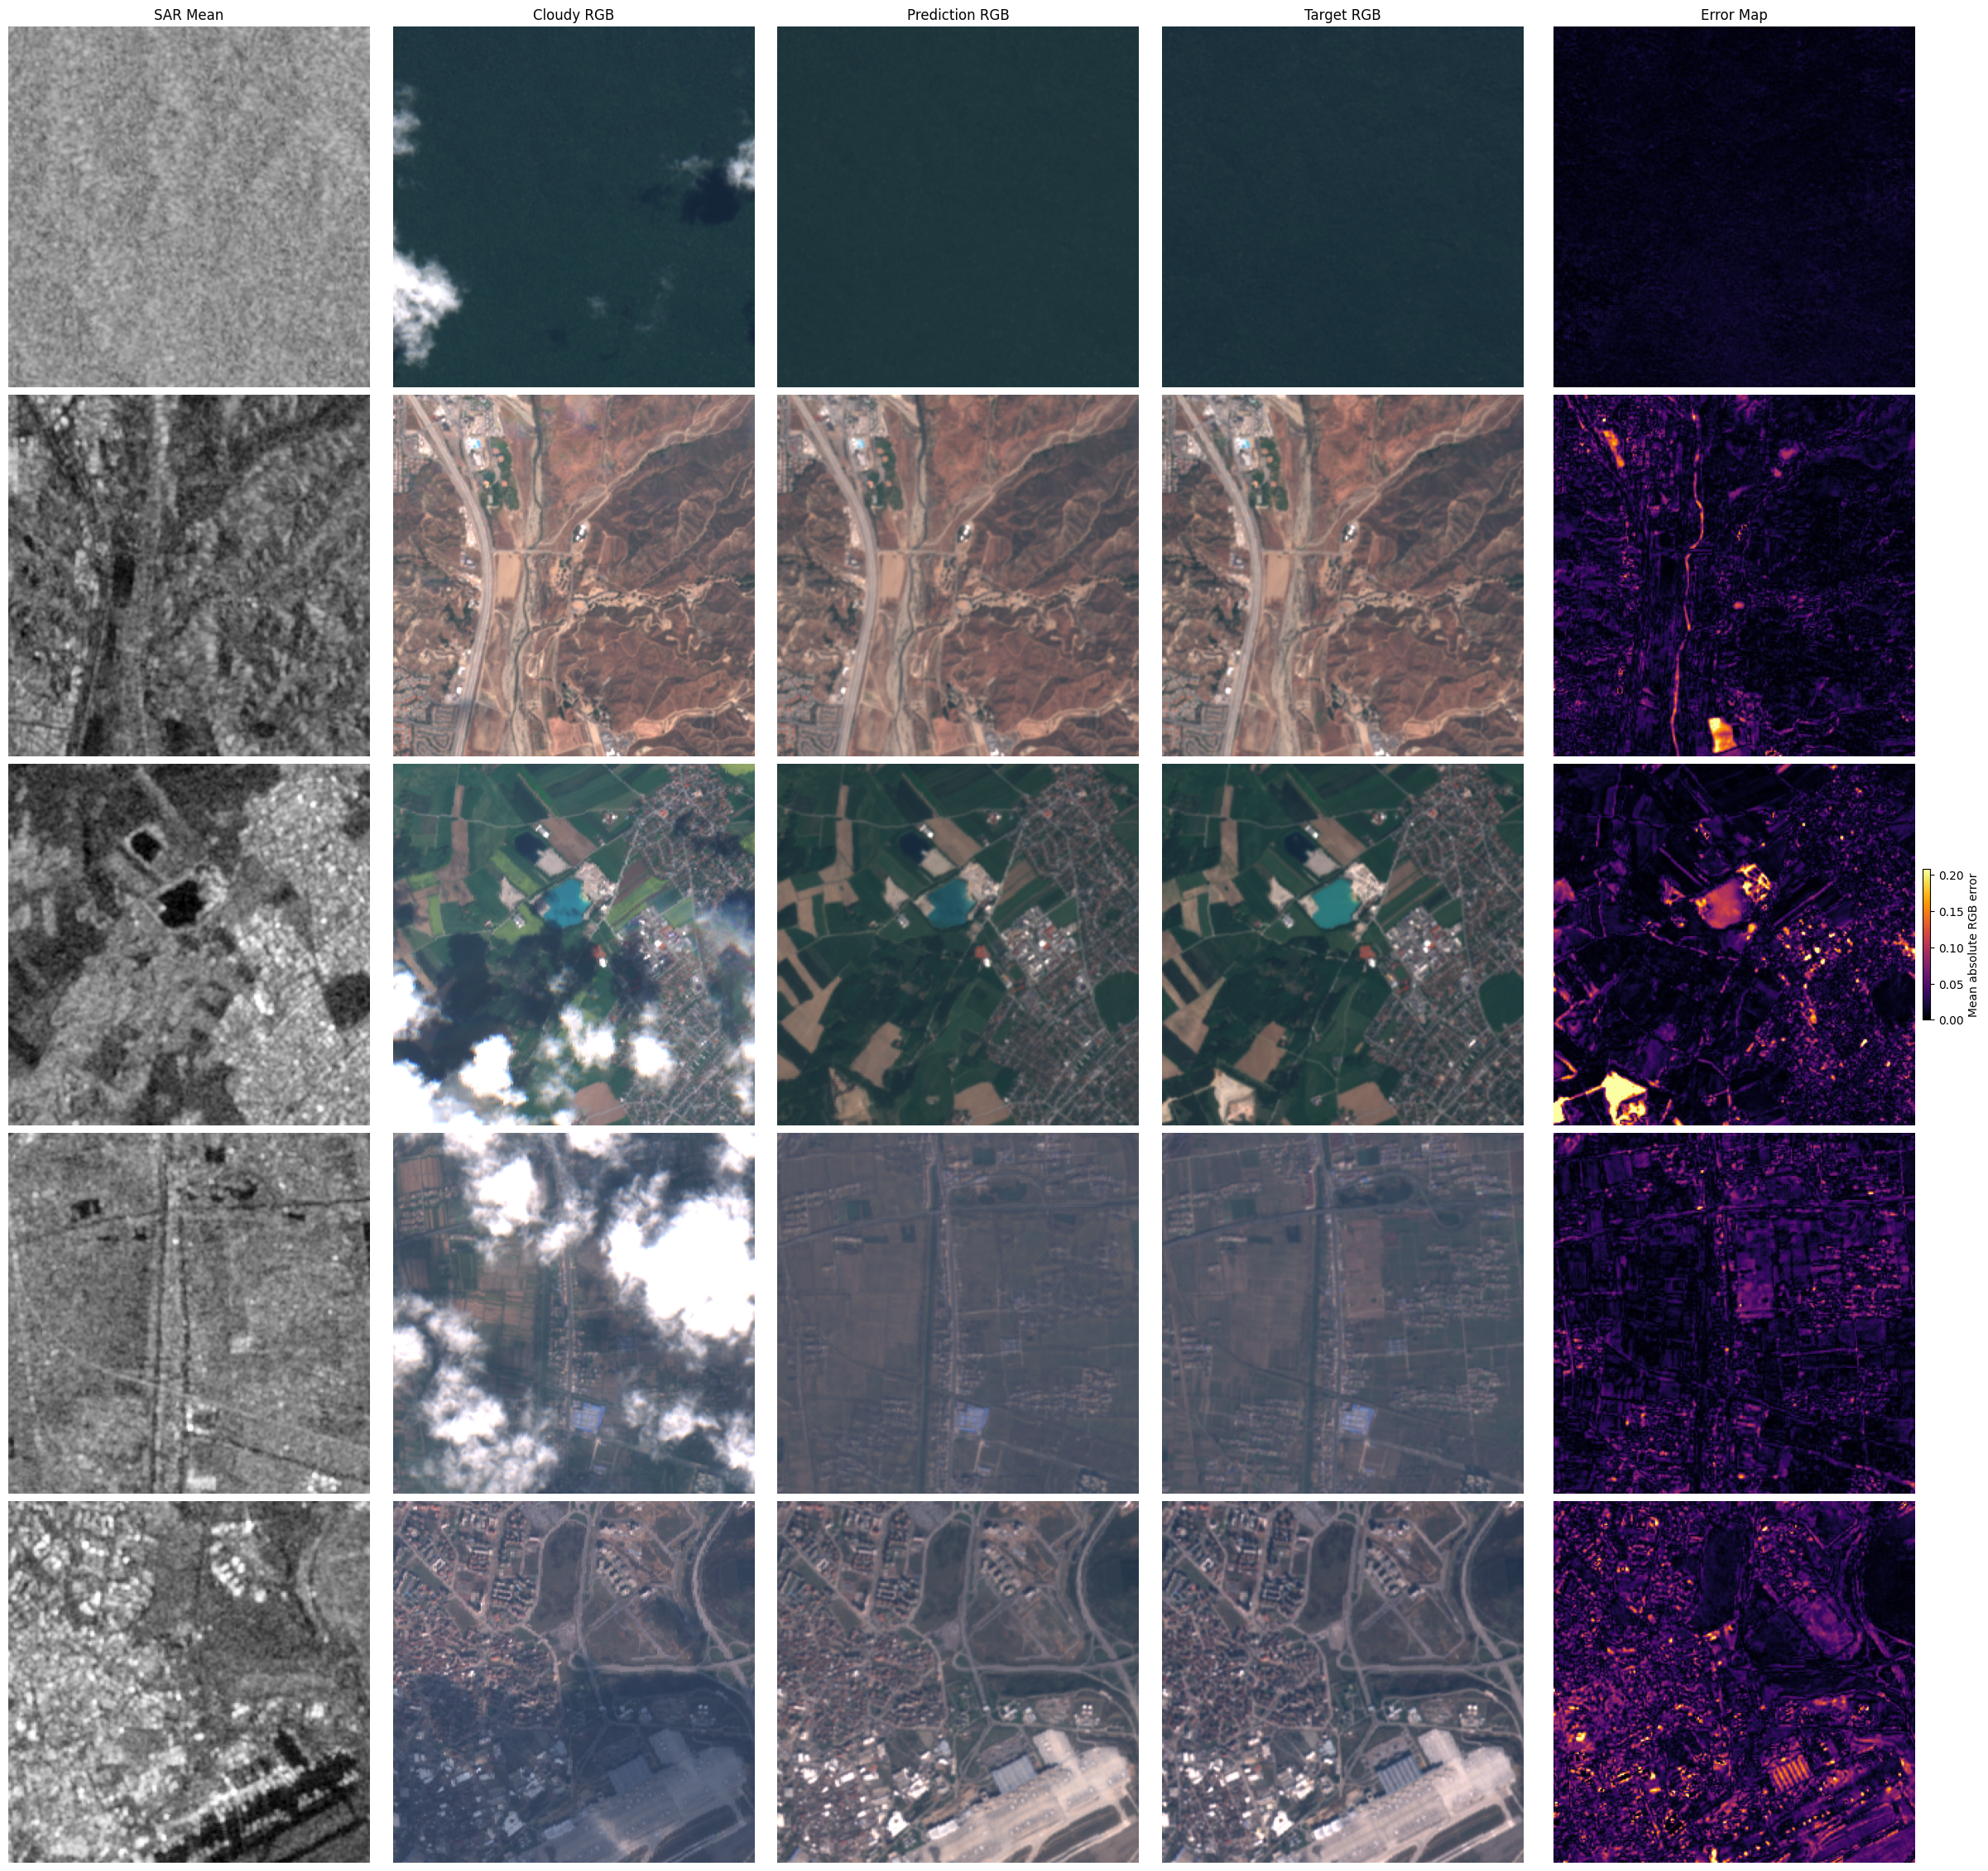

In [5]:
num_rows = len(records)
num_cols = 5
column_titles = ['SAR Mean', 'Cloudy RGB', 'Prediction RGB', 'Target RGB', 'Error Map']

error_vmax = max(np.percentile(record['error_map'], 99.0) for record in records)
error_vmax = max(float(error_vmax), 1e-6)

fig, axes = plt.subplots(
    num_rows,
    num_cols,
    figsize=(24, 4.5 * num_rows),
    squeeze=False,
    constrained_layout=True,
)
error_artist = None

for row_idx, record in enumerate(records):
    row_images = [
        (record['sar_mean'], {'cmap': 'gray', 'vmin': 0.0, 'vmax': 1.0}),
        (record['cloudy_rgb'], {}),
        (record['pred_rgb'], {}),
        (record['target_rgb'], {}),
        (record['error_map'], {'cmap': error_cmap, 'vmin': 0.0, 'vmax': error_vmax}),
    ]

    for col_idx, (image, image_kwargs) in enumerate(row_images):
        ax = axes[row_idx, col_idx]
        artist = ax.imshow(image, **image_kwargs)
        ax.axis('off')
        if row_idx == 0:
            ax.set_title(column_titles[col_idx])
        if col_idx == num_cols - 1:
            error_artist = artist

    axes[row_idx, 0].set_ylabel(
        f"idx={record['index']}\n{format_metrics(record['metrics'])}",
        rotation=0,
        ha='right',
        va='center',
        labelpad=85,
    )

if error_artist is not None:
    fig.colorbar(error_artist, ax=axes[:, -1], fraction=0.02, pad=0.02, label='Mean absolute RGB error')

plt.show()

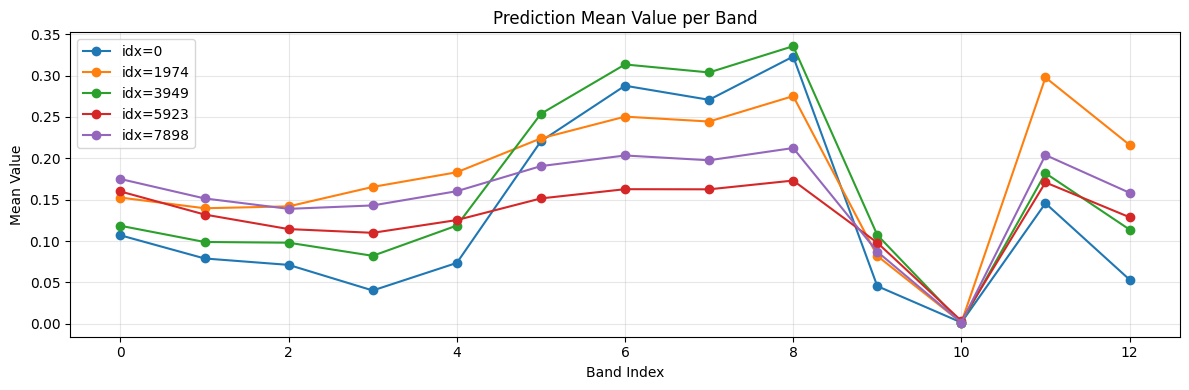

In [6]:
band_stat_records = []
for record in records:
    channel_means = get_prediction_band_means(record)
    if channel_means is not None:
        band_stat_records.append((record, channel_means))

if band_stat_records:
    plt.figure(figsize=(12, 4))
    for record, channel_means in band_stat_records:
        plt.plot(
            np.arange(len(channel_means)),
            channel_means,
            marker='o',
            label=f"idx={record['index']}"
        )
    plt.title('Prediction Mean Value per Band')
    plt.xlabel('Band Index')
    plt.ylabel('Mean Value')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print('Band statistics are available only when predictions are loaded from pred_npz.')